In [ ]:
# pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [111]:
# Import all necessary libraries
import pandas as pd 
import matplotlib.pyplot as plt
import re

In [79]:
# import data 
df_a = pd.read_csv("Part A with Supplier.csv")
df_b = pd.read_csv("Part B with Supplier.csv")

# Combine the two dataframes
frames = [df_a, df_b]
df = pd.concat(frames, ignore_index=True)

manufacturer_df = pd.read_csv("manufacturers_list.csv")
commodity_df = pd.read_csv("commodity_codes.csv")


C:\Users\ITafr\AppData\Local\Temp\ipykernel_31348\1418806870.py:2: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_a = pd.read_csv("Part A with Supplier.csv")
C:\Users\ITafr\AppData\Local\Temp\ipykernel_31348\1418806870.py:3: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,12,13,14,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_b = pd.read_csv("Part B with Supplier.csv")


In [80]:
display(manufacturer_df.head(2))
display(commodity_df.head(2))
display(df.head(2))


,Manufacturer,Name,Association No,Default Language,Country,Creation Date
0,NORA,Nora,3.0,NaN,UNITED STATES OF AME,3/13/2023
1,CNTB,Canterbury,3.0,NaN,UNITED STATES OF AME,3/13/2023


,Com 1,Commodity 1,Com 2,Commodity 2
0,1ADH,Adhesive,2ADH,Adhesive
1,1ACC,Accessories,2VNRB,Vinyl/Rubber


,PART_NO,DESCRIPTION,MFR,STYLE,COMPOSITION,WIDTH,COLOR,TYPE,SIZE,GAUGE,...,COMMODITY 2,PRODUCT CODE,PRODUCT_FAMILY,INV UoM,PURCH UoM,CONV FACTOR,PRIMARY SUPPLIER,SUPPLIER NAME,NET WEIGHT,NET VOLUME
0,1000042658,Miscellaneous Material - CTN,OTHR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2MISC,*,*,CTN,CTN,1.0,999999,SUPPLIER PLACEHOLDER,NaN,NaN
1,1000017103,Vortex 400g Orange,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2VCT,*,*,EA,EA,1.0,102549,"Aramsco, Inc.",NaN,NaN


In [81]:
# Merge df with manufacturer_df to get the manufacturer 'Name' based on 'MFR' and 'Manufacturer' columns
df = df.merge(manufacturer_df[['Manufacturer', 'Name']], how='left', left_on='MFR', right_on='Manufacturer')

# Insert the 'Name' column right after 'MFR'
mfr_index = df.columns.get_loc('MFR')
cols = list(df.columns)
# Remove 'Name' from the end and insert after 'MFR'
cols.insert(mfr_index + 1, cols.pop(cols.index('Name')))
df = df[cols]
# change the column name 'Name' to 'manufacturer_name'
df.rename(columns={'Name': 'manufacturer_name'}, inplace=True)
df.head(10)

,PART_NO,DESCRIPTION,MFR,manufacturer_name,STYLE,COMPOSITION,WIDTH,COLOR,TYPE,SIZE,...,PRODUCT CODE,PRODUCT_FAMILY,INV UoM,PURCH UoM,CONV FACTOR,PRIMARY SUPPLIER,SUPPLIER NAME,NET WEIGHT,NET VOLUME,Manufacturer
0,1000042658,Miscellaneous Material - CTN,OTHR,Other,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,CTN,CTN,1.0,999999,SUPPLIER PLACEHOLDER,NaN,NaN,OTHR
1,1000017103,Vortex 400g Orange,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,EA,EA,1.0,102549,"Aramsco, Inc.",NaN,NaN,NaN
2,1000042658,Miscellaneous Material - CTN,OTHR,Other,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,CTN,CTN,1.0,999999,SUPPLIER PLACEHOLDER,NaN,NaN,OTHR
3,1000008467,Schluter JOLLY 1/4in Brushed Nickel Anodized A...,SCTR,Schluter,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,EA,NaN,NaN,NaN,NaN,NaN,NaN,SCTR
4,1000008613,Schluter DESIGNLINE 1/4in Stainless Steel (DL6...,SCTR,Schluter,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,EA,NaN,NaN,NaN,NaN,NaN,NaN,SCTR
5,1000017336,Schluter JOLLY 1/2in Brushed Stainless Steel (...,SCTR,Schluter,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,EA,EA,1.0,999999,SUPPLIER PLACEHOLDER,NaN,NaN,SCTR
6,1000042658,Miscellaneous Material - CTN,OTHR,Other,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,CTN,CTN,1.0,999999,SUPPLIER PLACEHOLDER,NaN,NaN,OTHR
7,1000008613,Schluter DESIGNLINE 1/4in Stainless Steel (DL6...,SCTR,Schluter,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,EA,NaN,NaN,NaN,NaN,NaN,NaN,SCTR
8,1000008467,Schluter JOLLY 1/4in Brushed Nickel Anodized A...,SCTR,Schluter,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,EA,NaN,NaN,NaN,NaN,NaN,NaN,SCTR
9,1000017336,Schluter JOLLY 1/2in Brushed Stainless Steel (...,SCTR,Schluter,NaN,NaN,NaN,NaN,NaN,NaN,...,*,*,EA,EA,1.0,999999,SUPPLIER PLACEHOLDER,NaN,NaN,SCTR


In [82]:
# create a mapping dictionary
com1_map = dict(zip(commodity_df['Com 1'], commodity_df['Commodity 1']))
com2_map = dict(zip(commodity_df['Com 2'], commodity_df['Commodity 2']))

# map the values in the 'Com 1' and 'Com 2' columns
df['comm1_label'] = df['COMMODITY 1'].map(com1_map)
df['comm2_label'] = df['COMMODITY 2'].map(com2_map)

# Reorder the columns to place 'comm1_label' and 'comm2_label' after 'COMMODITY 1' and 'COMMODITY 2'
# Get the index of 'COMMODITY 2'
insert_at = df.columns.get_loc('COMMODITY 2') + 1
cols = df.columns.tolist()

# Remove the two new columns from wherever they were appended
cols.remove('comm1_label')
cols.remove('comm2_label')

# Insert them after 'COMMODITY 2'
cols.insert(insert_at, 'comm1_label')
cols.insert(insert_at + 1, 'comm2_label')

# Rebuild DataFrame with reordered columns
df = df[cols]

df.columns

Index(['PART_NO', 'DESCRIPTION', 'MFR', 'manufacturer_name', 'STYLE',
       'COMPOSITION', 'WIDTH', 'COLOR', 'TYPE', 'SIZE', 'GAUGE', 'FACE WEIGHT',
       'COLLECTION', 'DEPTH', 'BACKING', 'FINISH', 'SITE', 'PART STATUS',
       'PART TYPE', 'COMMODITY 1', 'COMMODITY 2', 'comm1_label', 'comm2_label',
       'PRODUCT CODE', 'PRODUCT_FAMILY', 'INV UoM', 'PURCH UoM', 'CONV FACTOR',
       'PRIMARY SUPPLIER', 'SUPPLIER NAME', 'NET WEIGHT', 'NET VOLUME',
       'Manufacturer'],
      dtype='object')

In [83]:
# How many null entries in part number
num_null_part_numbers = df['PART_NO'].isnull().sum()
print(f"Number of null entries in PART_NO: {num_null_part_numbers}")

Number of null entries in PART_NO: 0


In [84]:
# Unique descriptions
num_unique_descriptions = df['DESCRIPTION'].nunique()
print(f"Number of unique descriptions: {num_unique_descriptions}")

Number of unique descriptions: 399469


In [85]:
# Unique parts
num_unique_part = df['PART_NO'].nunique()
print(f"Number of unique Part numbers: {num_unique_descriptions}")

Number of unique Part numbers: 399469


Observation: <br>
    1) There are 399 469 unique parts <br>
    2) all part descriptions have unique part numbers 

In [86]:
# Return a DataFrame with unique descriptions
unique_df = df.drop_duplicates(subset=['DESCRIPTION'])
unique_df = unique_df.reset_index(drop=True)
unique_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399469 entries, 0 to 399468
Data columns (total 33 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   PART_NO            399469 non-null  object 
 1   DESCRIPTION        399469 non-null  object 
 2   MFR                376011 non-null  object 
 3   manufacturer_name  376011 non-null  object 
 4   STYLE              192485 non-null  object 
 5   COMPOSITION        158388 non-null  object 
 6   WIDTH              62103 non-null   object 
 7   COLOR              282124 non-null  object 
 8   TYPE               275301 non-null  object 
 9   SIZE               218560 non-null  object 
 10  GAUGE              142937 non-null  object 
 11  FACE WEIGHT        84555 non-null   object 
 12  COLLECTION         56964 non-null   object 
 13  DEPTH              22510 non-null   object 
 14  BACKING            130811 non-null  object 
 15  FINISH             59341 non-null   object 
 16  SI

In [87]:
# Miscellaneous descriptions
num_miscellaneous_descriptions = unique_df['DESCRIPTION'].str.contains('Miscellaneous', case=False, na=False).sum()
print(f"Number of descriptions with 'Miscellaneous': {num_miscellaneous_descriptions}")

Number of descriptions with 'Miscellaneous': 23


In [88]:
# Create a boolean mask for PART_NO in unique_df_clean that are also in df_miscellaneous
df_miscellaneous = unique_df[unique_df['DESCRIPTION'].str.contains('Miscellaneous', case=False, na=False)]
unique_df['miscellaneous'] = unique_df['PART_NO'].isin(df_miscellaneous['PART_NO'])

In [89]:
# Filter out rows where DESCRIPTION starts with "Material -" (case-sensitive) ---
df_material = unique_df[unique_df['DESCRIPTION'].str.startswith("Material -", na=False)]
df_material['DESCRIPTION'].nunique()

8

In [90]:
# Create a boolean mask for PART_NO in unique_df_clean that are also in df_material
unique_df['material_part'] = unique_df['PART_NO'].isin(df_material['PART_NO'])

In [91]:
# Lets get the manufacture extraction function (extract the first 1 to 3 capitalized words)
def extract_manufacture(description):
    try:
        # Match the first word (letters only), regardless of case
        match = re.match(r'^\s*([a-zA-Z]+)', str(description))
        return match.group(1).strip() if match else None
    except:
        return None

In [92]:
# Apply supplier extraction to the DESCRIPTION column
unique_df['ext_manufacturer'] = unique_df['DESCRIPTION'].apply(extract_manufacture)
print(unique_df['ext_manufacturer'].nunique())


7475


In [107]:
unique_df[unique_df['MFR'].isnull()].head(5)

,PART_NO,DESCRIPTION,MFR,manufacturer_name,STYLE,COMPOSITION,WIDTH,COLOR,TYPE,SIZE,...,CONV FACTOR,PRIMARY SUPPLIER,SUPPLIER NAME,NET WEIGHT,NET VOLUME,Manufacturer,miscellaneous,material_part,ext_manufacturer,manufacturer_match
1,1000017103,Vortex 400g Orange,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,102549,"Aramsco, Inc.",NaN,NaN,NaN,False,False,Vortex,False
5,1000024799,R.E. Whittaker Cover Drive (553360079),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,12,R.E. Whittaker Co.,NaN,NaN,NaN,False,False,R,False
6,1000024846,Spartan Chemical Green Solutions Carpet Cleane...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1181,Ferguson Facilities Supply,NaN,NaN,NaN,False,False,Spartan,False
7,1000013713,Mohawk Action Items (2B215) Ecoflex 24in x 24i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999999,SUPPLIER PLACEHOLDER,NaN,NaN,NaN,False,False,Mohawk,False
10,1000002140,Material - Sundry Carpet Glued Related,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,SUB,Sub contractor Place holder,NaN,NaN,NaN,False,True,Material,False


In [ ]:
# How many unique 
unique_null_manufacturers = unique_df[unique_df['MFR'].isnull()]['ext_manufacturer'].nunique()
print(unique_null_manufacturers)

3020


In [108]:
# # --- Filter out rows where DESCRIPTION starts with "Material" (case-sensitive) ---
# unique_df_clean = df[~df['DESCRIPTION'].str.startswith("Material", na=False)]

### Lets bite the pie one manufacure at a time <br> 
1) First we need to separate this big data by manufacture. <br> 
2) We need to filter by commodity. <br> 
3) We need to create a functions to extract all the relevant information. 

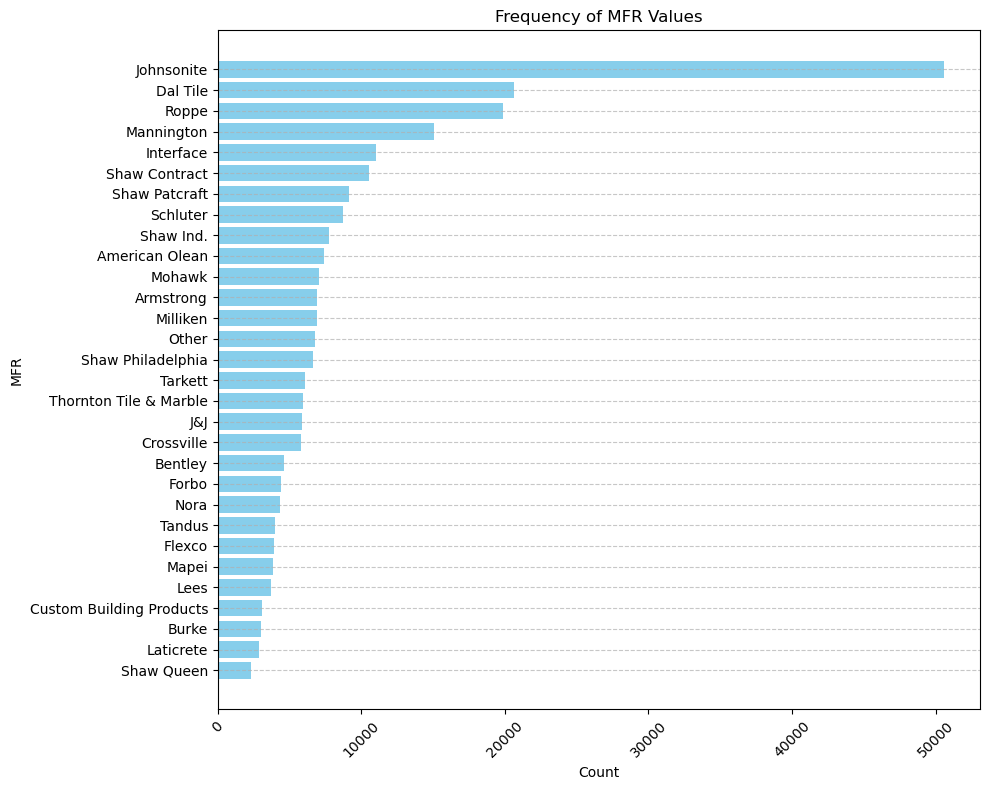

In [ ]:
# Count the frequency of each MFR value
mfr_counts = unique_df['manufacturer_name'].value_counts().head(30).sort_values(ascending=True)

# Plot the frequency as a bar chart
plt.figure(figsize=(10, 8))
plt.barh(mfr_counts.index, mfr_counts.values, color='skyblue')

# Add labels and formatting
plt.title("Frequency of MFR Values")
plt.xlabel("Count")
plt.ylabel("MFR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

## Interface

In [127]:
# df_interface = unique_df[unique_df['DESCRIPTION'].str.contains(r'^interface', case=False, na=False, regex=True)]
# df_interface.info()
df_interface = unique_df[unique_df['MFR'].isin(['INTF', 'IFFR', 'IFSTR'])].copy()
df_interface.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11786 entries, 278 to 399465
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PART_NO             11786 non-null  object 
 1   DESCRIPTION         11786 non-null  object 
 2   MFR                 11786 non-null  object 
 3   manufacturer_name   11786 non-null  object 
 4   STYLE               8661 non-null   object 
 5   COMPOSITION         533 non-null    object 
 6   WIDTH               554 non-null    object 
 7   COLOR               8637 non-null   object 
 8   TYPE                8667 non-null   object 
 9   SIZE                8170 non-null   object 
 10  GAUGE               832 non-null    object 
 11  FACE WEIGHT         8294 non-null   object 
 12  COLLECTION          0 non-null      object 
 13  DEPTH               0 non-null      object 
 14  BACKING             8346 non-null   object 
 15  FINISH              0 non-null      object 
 16  SITE  

In [ ]:
# Number of unique MFR values in df_interface
mfr_occurrences = df_interface['MFR'].value_counts()
print(mfr_occurrences)

MFR
INTF    11006
IFFR      780
Name: count, dtype: int64


In [140]:
# create a function to extract the relevant information from the description

# Regex for standard format

def extract_description_flexible(desc):
    if not isinstance(desc, str):
        return {}

    desc = desc.strip()

    # Normalize whitespace
    desc = re.sub(r'\s+', ' ', desc)

    # Pattern 1: Full standard format
    pattern_1 = re.compile(r"""^Interface(?:flor)?\s+
                                (?P<name>[^\(]+?)\s*
                                (?:\((?P<part_number>[^)]+)\))?\s+
                                (?P<product_type>\w+)\s+
                                (?P<form>(?:[\w&\+\-/]+\s*)+?)
                                (?P<dimensions>[\d\'\.]+\s*\w+\s+x\s+[\d\'\.]+\s*\w+(?:\s+[\d\'\.]+\s*\w+)?)
                                \s*[-–]\s*
                                (?P<color>.+?)\s*
                                \((?P<color_code>[^)]+)\)
                                $""", re.VERBOSE | re.IGNORECASE)
    match_1 = pattern_1.match(desc)
    if match_1:
        return match_1.groupdict()

    # Pattern 2: Backslash format (Windbid)
    if '\\' in desc:
        parts = desc.split('\\')
        if len(parts) == 4:
            return {
                'collection': parts[1].strip(),
                'product_name': parts[2].strip(),
                'backing': None,
                'dimensions': parts[3].strip(),
                'name': None, 'part_number': None,
                'product_type': None, 'form': None,
                'color': None, 'color_code': None
            }
        elif len(parts) == 5:
            return {
                'collection': parts[1].strip(),
                'product_name': parts[2].strip(),
                'backing': parts[3].strip(),
                'dimensions': parts[4].strip(),
                'name': None, 'part_number': None,
                'product_type': None, 'form': None,
                'color': None, 'color_code': None
            }
        elif len(parts) == 6:
            color_raw = parts[5].strip()
            color_code_match = re.match(r'COLOR-\s*(\d+)\s+(.+)', color_raw, re.IGNORECASE)
            if color_code_match:
                color_code = color_code_match.group(1)
                color_name = color_code_match.group(2)
            else:
                color_code = None
                color_name = color_raw
            return {
                'category': parts[1].strip(),
                'collection': parts[2].strip(),
                'product_number': parts[3].replace('PRODUCT #:', '').strip(),
                'backing': parts[4].strip(),
                'color': color_name,
                'color_code': color_code,
                'name': None, 'part_number': None,
                'product_type': None, 'form': None,
                'dimensions': None, 'product_name': None
            }

    # Pattern 3: No part number, but standard format
    pattern_3 = re.compile(r"""^Interface(?:flor)?\s+
                                (?P<name>\w+)\s+
                                (?P<product_type>\w+)\s+
                                (?P<form>(?:[\w&\+\-/]+\s*)+?)
                                (?P<dimensions>[\d\'\.]+\s*\w+\s+x\s+[\d\'\.]+\s*\w+)
                                \s*[-–]\s*
                                (?P<color>.+?)\s*
                                \((?P<color_code>[^)]+)\)
                                $""", re.VERBOSE | re.IGNORECASE)
    match_3 = pattern_3.match(desc)
    if match_3:
        return match_3.groupdict()

    # Pattern 4: Dash format - collection + product + backing
    pattern_4 = re.compile(r"""^Interface-
                                (?P<collection>[^\-]+)\s*-\s*
                                (?P<product_name>[^\(]+?)\s*
                                \((?P<part_number>[\w\-]+)\)-
                                (?P<backing>[^\-]+)-
                                (?P<dimensions>[\d\.]+\w+\s*x\s*[\d\.]+\w+)-
                                (?P<color>.+?)\s*
                                \((?P<color_code>[^)]+)\)
                                $""", re.VERBOSE | re.IGNORECASE)
    match_4 = pattern_4.match(desc)
    if match_4:
        return match_4.groupdict()

    # Pattern 5: Dash format - name + part number + form (no backing)
    pattern_5 = re.compile(r"""^Interface-
                                (?P<name>[^\(]+?)\s*
                                \((?P<part_number>[^)]+)\)-
                                (?P<form>[^-]+)-
                                (?P<dimensions>[\d\.]+\w+\s*x\s*[\d\.]+\w+)-
                                (?P<color>.+?)\s*
                                \((?P<color_code>[^)]+)\)
                                $""", re.VERBOSE | re.IGNORECASE)
    match_5 = pattern_5.match(desc)
    if match_5:
        return match_5.groupdict()

    # ✅ NEW Pattern 6: name + part number + dimensions + backing + color
    pattern_6 = re.compile(r"""^Interface(?:flor)?\s+
                                (?P<name>[^\(]+?)\s*
                                \((?P<part_number>[^)]+)\)\s+
                                (?P<dimensions>[\d\'\.]+\s*\w+\s*x\s*[\d\'\.]+\s*\w+|\d+\'\d*in)\s+
                                (?P<backing>[^\-]+)?\s*[-–]\s*
                                (?P<color>.+?)\s*
                                \((?P<color_code>[^)]+)\)
                                $""", re.VERBOSE | re.IGNORECASE)
    match_6 = pattern_6.match(desc)
    if match_6:
        return match_6.groupdict()

    # ✅ NEW Pattern 7: name + backing + dimension + color
    pattern_7 = re.compile(r"""^Interface(?:flor)?\s+
                                (?P<name>[^\d]+?)\s+
                                (?P<backing>[^\d]+)?\s*
                                (?P<dimensions>[\d\'\.]+\s*\w+(?:\s*x\s*[\d\'\.]+\s*\w+)?)
                                \s*[-–]\s*
                                (?P<color>.+?)\s*
                                \((?P<color_code>[^)]+)\)
                                $""", re.VERBOSE | re.IGNORECASE)
    match_7 = pattern_7.match(desc)
    if match_7:
        return match_7.groupdict()

    # Fallback if no match
    return {
        'collection': None,
        'product_name': None,
        'backing': None,
        'dimensions': None,
        'name': None,
        'part_number': None,
        'product_type': None,
        'form': None,
        'color': None,
        'color_code': None
    }

In [144]:
df_sample = df_interface.sample(150, random_state=56)
df_sample['windbid'] = df_sample['DESCRIPTION'].apply(lambda x: 'Yes' if isinstance(x, str) and '\\' in x else 'No')

display(df_sample.head())


,PART_NO,DESCRIPTION,MFR,manufacturer_name,STYLE,COMPOSITION,WIDTH,COLOR,TYPE,SIZE,...,PRIMARY SUPPLIER,SUPPLIER NAME,NET WEIGHT,NET VOLUME,Manufacturer,miscellaneous,material_part,ext_manufacturer,manufacturer_match,windbid
299975,183916-012,Interface Silver Linings SL910 (SL910) Tufted ...,INTF,Interface,5591 - Silver Linings SL910,NaN,NaN,40161 - Walnut (104509),2023 - Tufted Texture Loop,903 - 25cm x 1m,...,102775.0,"Interface Americas, Inc.",NaN,NaN,INTF,False,False,Interface,True,No
387601,215819-001,Interface Cubic (1380102501) Tufted Texture Lo...,INTF,Interface,7094 - Cubic,NaN,NaN,30077 - Shape (4287),2023 - Tufted Texture Loop,494 - 19.69in x 19.69in,...,102775,"Interface Americas, Inc.",NaN,NaN,INTF,False,False,Interface,True,No
250912,162621-020,Interface Cap & Blazer Tufted Texture Loop 19....,INTF,Interface,715 - Cap & Blazer,NaN,NaN,55171 - St. George (100888),2023 - Tufted Texture Loop,494 - 19.69in x 19.69in,...,102775.0,"Interface Americas, Inc.",NaN,NaN,INTF,False,False,Interface,True,No
58441,004001,INTERFACE\NATIVE FABRIC\A00806 TWINE\50CMX50CM,INTF,Interface,NaN,NaN,NaN,NaN,NaN,NaN,...,100796,DNU (102775) Interface Americas,NaN,NaN,INTF,False,False,INTERFACE,True,Yes
252939,153104-015,Interfaceflor Block Weave (12504) Tufted Cut &...,IFFR,Interfaceflor,2880 - Block Weave,NaN,NaN,120556 - Mercury (8052),1996 - Tufted Cut & Loop,494 - 19.69in x 19.69in,...,102775.0,"Interface Americas, Inc.",NaN,NaN,IFFR,False,False,Interfaceflor,True,No


In [145]:
extracted_sample = df_sample['DESCRIPTION'].apply(extract_description_flexible).apply(pd.Series)
df_sample_normalized = pd.concat([df_sample, extracted_sample], axis=1)

# Define which fields you'd expect to be filled if processing was successful
key_fields = [
    'name', 'part_number', 'product_type', 'form', 'dimensions',
    'collection', 'product_name', 'backing', 'color', 'color_code'
]

# Create the flag
df_sample_normalized['processed_flag'] = df_sample_normalized[key_fields].notnull().any(axis=1).map({True: 'Processed', False: 'Not Processed'})

display(df_sample_normalized.head())

,PART_NO,DESCRIPTION,MFR,manufacturer_name,STYLE,COMPOSITION,WIDTH,COLOR,TYPE,SIZE,...,part_number,product_type,form,dimensions,color,color_code,collection,product_name,backing,processed_flag
299975,183916-012,Interface Silver Linings SL910 (SL910) Tufted ...,INTF,Interface,5591 - Silver Linings SL910,NaN,NaN,40161 - Walnut (104509),2023 - Tufted Texture Loop,903 - 25cm x 1m,...,SL910,Tufted,Texture Loop,25cm x 1m,Walnut,104509,NaN,NaN,NaN,Processed
387601,215819-001,Interface Cubic (1380102501) Tufted Texture Lo...,INTF,Interface,7094 - Cubic,NaN,NaN,30077 - Shape (4287),2023 - Tufted Texture Loop,494 - 19.69in x 19.69in,...,1380102501,Tufted,Texture Loop,19.69in x 19.69in,Shape,4287,NaN,NaN,NaN,Processed
250912,162621-020,Interface Cap & Blazer Tufted Texture Loop 19....,INTF,Interface,715 - Cap & Blazer,NaN,NaN,55171 - St. George (100888),2023 - Tufted Texture Loop,494 - 19.69in x 19.69in,...,None,Blazer,Tufted Texture Loop,19.69in x 19.69in,St. George,100888,NaN,NaN,NaN,Processed
58441,004001,INTERFACE\NATIVE FABRIC\A00806 TWINE\50CMX50CM,INTF,Interface,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,50CMX50CM,None,None,NATIVE FABRIC,A00806 TWINE,None,Processed
252939,153104-015,Interfaceflor Block Weave (12504) Tufted Cut &...,IFFR,Interfaceflor,2880 - Block Weave,NaN,NaN,120556 - Mercury (8052),1996 - Tufted Cut & Loop,494 - 19.69in x 19.69in,...,12504,Tufted,Cut & Loop,19.69in x 19.69in,Mercury,8052,NaN,NaN,NaN,Processed


In [143]:
df_sample_normalized.to_csv("df_sample_normalized_v3.csv", index=True)

### Create a new naming convention 

In [ ]:
# nomenclature_columns = [
#     'category', 'collection', 'product_name', 'product_number',
#     'backing', 'dimensions', 'name', 'part_number',
#     'product_type', 'form', 'color', 'color_code'
# ]


# def create_nomenclature(row):
#     values = [str(row[col]) if pd.notnull(row.get(col)) else "N/A" for col in nomenclature_columns]
#     return "Interface Inc - " + "-".join(values)



In [ ]:
# # Apply the nomenclature creation function to each row
# df_sample_normalized['new_nomenclature'] = df_sample_normalized.apply(create_nomenclature, axis=1)

In [ ]:
# df_sample_normalized.to_csv("df_sample_normalized_with_nomenclature.csv", index=True)